### SEA4001W: Advanced Python Applications: P4: Final Assignment
MNKREB002 Rebecca Monk - March 2026

#### Set-Up
import the packages needed and set the working directory

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import calendar

os.chdir("/Users/rebeccamonk/Desktop/MNKREB002-SCDM2026/P4")

#### Part 1: Bathymetry Map of the South-West Coast of England

In [2]:
# load the bathymetry dataset
bathymetry = xr.open_dataset("./GMRTv4_4_1_20260319topo.grd")

In [3]:
# look at the metadata (used to write the dataset descriptions)
bathymetry.info() # this displays the dataset information with more detail

# list the variables (with dimensions) of the dataset
bathymetry.data_vars 
# altitude is the only variable
bathymetry["altitude"] # this indcates the unit and the range 
bathymetry.coords # this visualises the dataset coordinates to understand the spatial resolution

bathymetry.attrs # this shows the attributes (metadata) like the data source

xarray.Dataset {
dimensions:
	lat = 535 ;
	lon = 912 ;

variables:
	float64 altitude(lat, lon) ;
		altitude:long_name = altitude ;
		altitude:standard_name = altitude ;
		altitude:units = m ;
		altitude:actual_range = [-176.20337356  596.91419509] ;
	float64 lon(lon) ;
		lon:units = degree_east ;
		lon:long_name = longitude ;
		lon:actual_range = [-6.00732422 -1.99951172] ;
	float64 lat(lat) ;
		lat:units = degree_north ;
		lat:long_name = latitude ;
		lat:actual_range = [49.49952866 51.00269435] ;

// global attributes:
	:title = GMRT Grid ;
	:history = Projection: Cylindrical Equidistant
Extracted from the Global Multi-Resolution Topgraphy (GMRT) Synthesis v4
https://www.gmrt.org
Created with GMRT GridServer
https://www.gmrt.org/services/gridserverinfo.php ;
	:Conventions = COARDS,CF-1.6 ;
	:GMT_version = 4.5.7 ;
}

{'title': 'GMRT Grid',
 'history': 'Projection: Cylindrical Equidistant\nExtracted from the Global Multi-Resolution Topgraphy (GMRT) Synthesis v4\nhttps://www.gmrt.org\nCreated with GMRT GridServer\nhttps://www.gmrt.org/services/gridserverinfo.php',
 'Conventions': 'COARDS,CF-1.6',
 'GMT_version': '4.5.7'}

In [4]:
bathymetry # this is the representation of the xarry dataset (the summary of the dataset)

<xarray.Dataset> Size: 4MB
Dimensions:   (lat: 535, lon: 912)
Coordinates:
  * lat       (lat) float64 4kB 49.5 49.5 49.51 49.51 ... 50.99 51.0 51.0 51.0
  * lon       (lon) float64 7kB -6.007 -6.003 -5.999 ... -2.008 -2.004 -2.0
Data variables:
    altitude  (lat, lon) float64 4MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7

since the metadata (the source and the history) have been included in the attributes, the data management plan was good

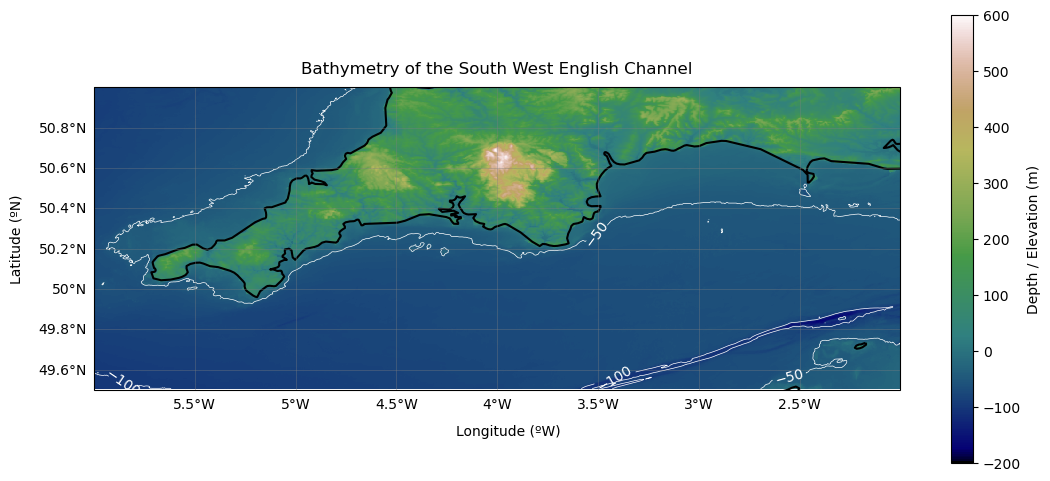

In [5]:
# plot a map of the bathymetry
fig = plt.figure(figsize = (12, 8))
axis = plt.axes(projection=ccrs.PlateCarree())
plt.subplots_adjust(left = 0.08, right = 0.92, top = 0.9, bottom = 0.1)
# the historical projection is Cylindrical Equidistant
# the data CRS is Plate Carree and the map CRS is in Plate Carree so no transformation is required

bathymetry.altitude.plot(ax = axis, transform = ccrs.PlateCarree(), cmap = "gist_earth", vmin = -200, vmax = 600, 
                         cbar_kwargs = {"label":"Depth / Elevation (m)", "shrink":0.7, "pad":0.05})

# add contour lines
contours = axis.contour(bathymetry.lon.values, bathymetry.lat.values, bathymetry.altitude.values, 
                        levels = [-100, -50], colors = "white", linewidths = 0.5, linestyles = "-",
                        transform = ccrs.PlateCarree())
axis.clabel(contours, fontsize = 10)

# add cartopy features to the map
axis.set_extent([-6, -2, 49.5, 51], crs = ccrs.PlateCarree())
axis.coastlines(resolution = "10m", linewidth = 1.5)

# add gridlines with coordinates
gl = axis.gridlines(draw_labels = True, linewidth = 0.5, color = "gray", alpha = 0.5, linestyle = "-")
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# add a title and axis labels (and setting the position of the axis labels)
plt.title("Bathymetry of the South West English Channel", fontsize = 12, pad = 10)

fig.supxlabel("Longitude (ºW)", x = 0.425, y  = 0.25, fontsize = 10)
fig.supylabel("Latitude (ºN)", x = 0.01, fontsize = 10)

plt.show()

#### Part 2: Map of Mean Annual Chlorophyll (with a log scale)

In [6]:
# load the chlorophyll dataset
chlorophyll = xr.open_dataset("./ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

In [7]:
# look at the metadata (used to write the dataset descriptions)
chlorophyll.info() # this displays the dataset information

# list the variables (with dimensions) of the dataset
chlorophyll.data_vars 
# there is one variable and the coordinate reference system: chlor_a and crs

# look at each variable
chlorophyll["crs"] # this indcates the unit of the coordinates (latitude and longitude)
chlorophyll["chlor_a"] # this indcates the unit of chlorophyll-a
chlorophyll.coords # this visualises the dataset coordinates to understand the spatial resolution

chlorophyll.attrs # this shows the attributes (metadata)

xarray.Dataset {
dimensions:
	time = 12 ;
	lat = 4320 ;
	lon = 8640 ;

variables:
	int32 crs() ;
		crs:grid_mapping_name = latitude_longitude ;
	float32 chlor_a(time, lat, lon) ;
		chlor_a:standard_name = mass_concentration_of_chlorophyll_a_in_sea_water ;
		chlor_a:long_name = Chlorophyll-a concentration in seawater (not log-transformed), generated by as a blended combination of OCI, OCI2, OC2 and OCx algorithms, depending on water class memberships ;
		chlor_a:units = milligram m-3 ;
		chlor_a:grid_mapping = crs ;
		chlor_a:ancillary_variables = chlor_a_log10_rmsd chlor_a_log10_bias ;
		chlor_a:parameter_vocab_uri = http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU ;
		chlor_a:units_nonstandard = mg m^-3 ;
	datetime64[ns] time(time) ;
		time:standard_name = time ;
		time:axis = T ;
	float64 lon(lon) ;
		lon:standard_name = longitude ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
		lon:axis = X ;
	float64 lat(lat) ;
		lat:standard_name = latitude ;
		lat:long_name = 

{'CDI': 'Climate Data Interface version ?? (http://mpimet.mpg.de/cdi)',
 'history': 'Tue Apr 27 20:27:21 2021: cdo selvar,chlor_a ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc\nTue Apr 27 19:42:57 2021: ncrcat ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-01-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-02-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-03-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-04-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-05-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-06-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-07-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-08-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-09-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_OCx_QAA-10-fv5.0.nc ESACCI-OC-MAPPED-CLIMATOLOGY-1

In [8]:
chlorophyll # this is the representation of the xarry dataset

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

since the metadata (the source and the history) have been included in the attributes, the data management plan was good

In [9]:
# calculate the annual mean
chlora_mean = chlorophyll["chlor_a"].mean(dim = "time", skipna = True) # skip NaNs to avoid the land data
print(chlora_mean.dims) # only latitude and longitude appear as dimensions (the 3D array has become a 2D array)
print(chlora_mean.min().values) 
print(chlora_mean.max().values) 
print(chlora_mean.mean().values) 
# the mean values are used to define the colourbar range later on: 0.001, 93.51422, 0.4926619

('lat', 'lon')
0.001
93.51422
0.4926619


In [10]:
# define the extent of the region
extent = [-6, -2, 49.5, 51]
# use the extent to create the region
chlora_mean_region = chlora_mean.sel(lon = slice(extent[0], extent[1]), lat = slice(extent[3], extent[2])) 

In [11]:
# check the mean values for the region
print("Min:", chlora_mean_region.min().values) 
print("Max:", chlora_mean_region.max().values) 
print("Mean:", chlora_mean_region.mean().values) 
# the mean values are used to define the colourbar range later on: 0.73415095, 13.200992, 1.1085846

Min: 0.73415095
Max: 13.200992
Mean: 1.1085846


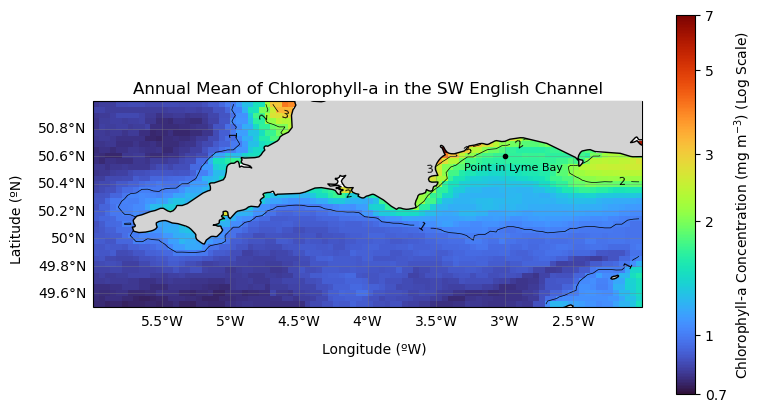

In [12]:
# plot the mean annual chlorophyll (log scale)
fig = plt.figure(figsize = (8, 6))
axis = plt.axes(projection=ccrs.PlateCarree())

pcm = chlora_mean_region.plot.pcolormesh(ax = axis, transform = ccrs.PlateCarree(), cmap = "turbo", norm = LogNorm(vmin = 0.7, vmax = 7), add_colorbar = False)

# add the colourbar
cbar = plt.colorbar(pcm, ax = axis, orientation = "vertical", pad = 0.05, shrink = 0.7)
cbar.set_ticks([0.7, 1, 2, 3, 5, 7])
cbar.set_ticklabels(["0.7", "1", "2", "3", "5", "7"])
cbar.set_label("Chlorophyll-a Concentration (mg m$^{-3}$) (Log Scale)", fontsize = 10)
cbar.ax.minorticks_off()

# add contour lines
contours = axis.contour(chlora_mean_region.lon.values, chlora_mean_region.lat.values, chlora_mean_region.values, 
                        levels = [1, 2, 3], colors = "black", linewidths = 0.5, linestyles = "-",
                        transform = ccrs.PlateCarree())
axis.clabel(contours, fontsize = 8)

# add cartopy features to the map
axis.set_extent(extent)
axis.coastlines(resolution = "10m", linewidth = 1, zorder = 4)
axis.add_feature(cf.LAND, facecolor = "lightgray", zorder = 3)

# add gridlines with coordinates
gl = axis.gridlines(draw_labels = True, color = "gray", linewidth = 0.5, alpha = 0.5)
gl.right_labels = False
gl.top_labels = False

# add a title and axis labels (and setting the position of the axis labels)
plt.title("Annual Mean of Chlorophyll-a in the SW English Channel")
fig.supxlabel("Longitude (ºW)", x = 0.475, y  = 0.27, fontsize = 10)
fig.supylabel("Latitude (ºN)", x = 0.02, fontsize = 10)

# add a marker for the point in Lyme Bay used in the timeseries: 50.6ºN and 3ºW
axis.plot(-3, 50.6, marker = "o", markersize = 3, color = "black", transform = ccrs.PlateCarree(), zorder = 5)
axis.text(-3.3, 50.5, "Point in Lyme Bay", fontsize = 8, color = "black", transform = ccrs.PlateCarree(), zorder = 6)

# show the plot
plt.tight_layout()
plt.show()

#### Part 3: Faceted Figure Showing Monthly Chlorophyll Means

In [13]:
# group the chlorophyll data into seasons
monthly_chlora = chlorophyll.groupby("time.month") # this groups the data into monthly bins
monthly_mean_chlora = chlorophyll.groupby("time.month").mean("time") # this averages all of the years in the group
monthly_mean_chlora["month"]
monthly_mean_chlora # this displays the data

<xarray.Dataset> Size: 2GB
Dimensions:  (month: 12, lat: 4320, lon: 8640)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      (month) float64 96B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    chlor_a  (month, lat, lon) float32 2GB nan nan nan nan ... nan nan nan nan
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [14]:
# define the region for the monthly data
mmc_region = monthly_mean_chlora["chlor_a"].sel(lon = slice(extent[0], extent[1]), lat = slice(extent[3], extent[2])) 

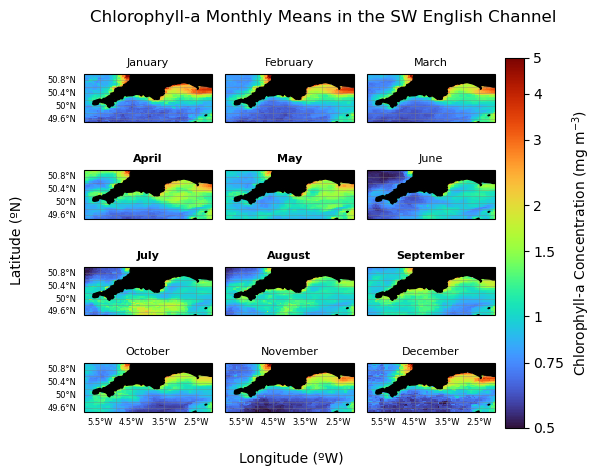

In [15]:
# plot the 12 maps 
fig, axes = plt.subplots(4, 3, subplot_kw = {"projection":ccrs.PlateCarree()})
axes = axes.flatten()

for m in range(12):
    ax = axes[m]
    pcm = mmc_region.isel(month=m).plot.pcolormesh(ax = ax, transform = ccrs.PlateCarree(), cmap = "turbo", norm = LogNorm(vmin = 0.5, vmax = 5), add_colorbar = False)
    
    ax.coastlines(zorder = 4)
    ax.set_extent([-6, -2, 49.5, 51], crs = ccrs.PlateCarree())
    ax.add_feature(cf.LAND, facecolor = "black", zorder = 3)
    
    # highlight the spring bloom months by making the month names bold
    if m in [3, 4, 6, 7, 8]:
        ax.set_title(calendar.month_name[m+1], fontsize = 8, fontweight = "bold")
    else:
        ax.set_title(calendar.month_name[m+1], fontsize = 8)
    
    # add the gridlines 
    gl = ax.gridlines(draw_labels = True, linewidth = 0.5, color = "gray", alpha = 0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    # only label the axes on the outer subplots (this makes the figure look cleaner)
    if m % 3 != 0:
        gl.left_labels = False
    if m < 9:
        gl.bottom_labels = False
    
    # set the label size
    gl.xlabel_style = {"size": 6}
    gl.ylabel_style = {"size": 6}

# adjust the spacing between the subplots
fig.subplots_adjust(wspace = 0.1, hspace = 0.2)

# add the colourbar
cbar = fig.colorbar(pcm, ax = axes, orientation = "vertical", pad = 0.02)
cbar.set_ticks([0.5, 0.75, 1, 1.5, 2, 3, 4, 5])
cbar.set_ticklabels(["0.5", "0.75", "1", "1.5", "2", "3", "4", "5"])
cbar.ax.minorticks_off()
cbar.set_label("Chlorophyll-a Concentration (mg m$^{-3}$)", fontsize = 10)

# add a title and axis labels (and set the position of the axis labels)
fig.suptitle("Chlorophyll-a Monthly Means in the SW English Channel")
fig.supxlabel("Longitude (ºW)", x = 0.45, y  = 0.03, fontsize = 10)
fig.supylabel("Latitude (ºN)", x = 0.01, fontsize = 10)

# show the plot
plt.show()

#### Part 4: Timeseries Showing the Mean Seasonal Cycle 

In [16]:
# create the datasets
# mean chlorophyll for the region
chlora = chlorophyll["chlor_a"] # create a dataArray from the dataSet
monthly_mean_chlora = chlora.groupby("time.month").mean("time") # this is the monthly mean of the dataArray
mmc_region = monthly_mean_chlora.sel(lon = slice(extent[0], extent[1]), lat = slice(extent[3], extent[2])).mean(dim = ["lat", "lon"])

# mean chlorophyll at a point
lat_point = 50.6 # this point contains high concentrations of chlorophyll for most of the year as it is close to the coast
long_point = -3
# define the point by selecting the grid cell closest to the chosen latitude and longitude 
chlora_point = chlora.sel(lat = lat_point, lon = long_point, method = "nearest") 
chlora_point_monthly = chlora_point.groupby("time.month").mean("time") # this is the monthly mean of the point

In [17]:
# check the shape of the data
print(mmc_region.shape)
print(chlora_point_monthly.shape)

(12,)
(12,)


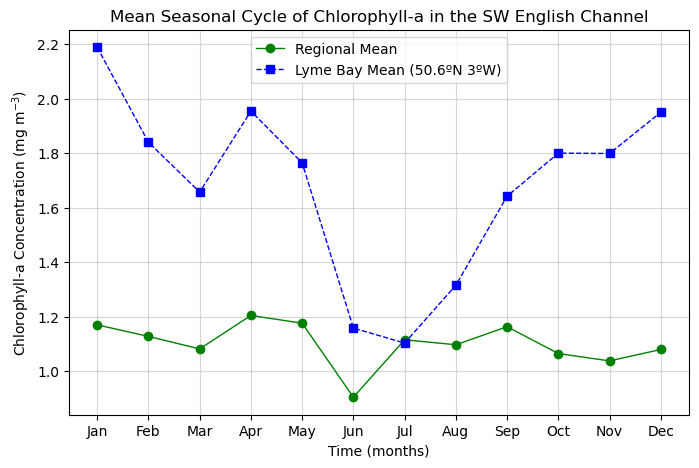

In [18]:
# plot the timeseries
fig, ax = plt.subplots(figsize = (8, 5))

# plot the region 
ax.plot(mmc_region["month"], mmc_region, label = "Regional Mean", linewidth = 1, color = "g", marker = "o")

# plot the point
ax.plot(chlora_point_monthly["month"], chlora_point_monthly, label = "Lyme Bay Mean (50.6ºN 3ºW)", linestyle ="--", linewidth = 1, color = "b", marker = "s")

# add labels
ax.set_xlabel("Time (months)")
ax.set_ylabel("Chlorophyll-a Concentration (mg m$^{-3}$)")
ax.set_title("Mean Seasonal Cycle of Chlorophyll-a in the SW English Channel")

# add tick marks 
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

# add a legend and gridlines
ax.legend(loc = "upper center")
ax.grid(alpha = 0.5)

# show the plot
plt.show()